# Spotify Popularity Prediction — CISC 4631
**Patch Shields | Group 3**

### Research Questions
1. Can audio features predict whether a song will be **globally popular**?
2. Can audio features predict whether a song will be popular **within its genre**?
3. Do the same features drive both, or does genre context change what matters?


### To-do:
- Group Jazz/Blues/R&B (?) and/or country/folk (?)
-


### Pipeline
1. Load & Explore
2. Sample (stratified, balanced)
3. Preprocess & Engineer Labels
4. Baseline Classifiers (KNN, Decision Tree, Naive Bayes)
5. Neural Network (PyTorch MLP)
6. Compare & Analyze

---
# What's Done
1. Data Analysis (Section 2)
* Key findings: all individual feature correlations with popularity are weak (<0.15), suggesting non-linear models and feature interactions matter more

2. Sampling
* Filtered to 2010+ songs (290,872)
* Created two label systems:
  * Global popularity: binned 0-20 / 21-45 / 46+ $\to$ low/mid/high
  * Genre-relative popularity: percentile rank within genre $\to$ thirds
* Stratified sample: 500 songs per (popularity_class, genre) pair $\to$ 14,537 songs, balanced across all 10 genres

3. Preprocessing
* 12 features (10 audio + key + mode), MinMaxScalar applied
* 80/20 train/test split (11,629 / 2,908), stratified

4. Baseline Classifiers on Global Target (5.1)
* KNN (k=5): 35% accuracy
* Naive Bayes: 39% accuracy (but biased --  72% recall on High, only 16% on Mid)
* All models struggle --- confirms that audio features alone are weak global predictors
---

# 0. Setup

In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB

import warnings
warnings.filterwarnings('ignore')

SEED = 42
np.random.seed(SEED)

# 1. Load Data

In [31]:
import os
import kagglehub as kh

path = kh.dataset_download("serkantysz/550k-spotify-songs-audio-lyrics-and-genres")
print("Dataset path:",path)
df = pd.read_csv(os.path.join(path, 'songs.csv'))
print(f'Loaded {len(df):,} songs | {df.shape[1]} columns')
df.head()

Using Colab cache for faster access to the '550k-spotify-songs-audio-lyrics-and-genres' dataset.
Dataset path: /kaggle/input/550k-spotify-songs-audio-lyrics-and-genres
Loaded 550,622 songs | 24 columns


,id,name,album_name,artists,danceability,energy,key,loudness,mode,speechiness,...,tempo,duration_ms,lyrics,year,genre,popularity,total_artist_followers,avg_artist_popularity,artist_ids,niche_genres
0,0Prct5TDjAnEgIqbxcldY9,!,UNDEN!ABLE,"[""HELLYEAH""]",0.415,0.605,7,-11.157,1,0.0575,...,100.059,79500,"He said he came from Jamaica,\nhe owned a coup...",2016,Rock,0,769490,52.0,"[""4hxDvVq5t8ebPYPdBl1F9f""]","[""groove metal"", ""metal""]"
1,2ASl4wirkeYm3OWZxXKYuq,!!,Childhood Dreams,"[""Yxngxr1""]",0.788,0.648,7,-9.135,0,0.3150,...,79.998,114000,"Fuck the bitch, now she running with my kids\n...",2019,Hip-Hop,29,143628,45.0,"[""2jwRHcdgkRhelYEMqndDKe""]",[]
2,5tA3ImW310llKo8EMBj2Ga,!!Noble Stabbings!!,Situationist Comedy,"[""Dillinger Four""]",0.171,0.957,2,-5.749,1,0.1490,...,175.317,197400,You like to stand on the other side\nPoint and...,2002,Rock,0,36619,35.0,"[""4YAN46l70QV0PGXlMg0iHi""]","[""melodic hardcore"", ""pop punk"", ""punk"", ""skat..."
3,0fROT4kK5oTm8xO8PX6EJF,!I'll Be Back!,!I'll Be Back!,"[""Ril\u00e8s""]",0.823,0.612,1,-7.767,1,0.2480,...,142.959,178533,"It's been a while, shit, I missed the rehab, p...",2018,Hip-Hop,43,929303,63.0,"[""6pdcQa7by8IKuoVXvgknlI""]","[""french rap""]"
4,1xBFhv5faebv3mmwxx7DnS,!Lost!,!Lost!,"[""Ril\u00e8s""]",0.729,0.552,7,-8.562,0,0.0650,...,86.103,186197,I would like to give you all my time\nI would ...,2018,Hip-Hop,0,929303,63.0,"[""6pdcQa7by8IKuoVXvgknlI""]","[""french rap""]"


# 2. Exploration

In [33]:
# -- 2.1 Basic Info --
print(df.info())
print('\nMissing Values:')
missing = df.isnull().sum()
print(missing[missing > 0])

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 550622 entries, 0 to 550621
Data columns (total 24 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   id                      550622 non-null  object 
 1   name                    550619 non-null  object 
 2   album_name              550602 non-null  object 
 3   artists                 550622 non-null  object 
 4   danceability            550622 non-null  float64
 5   energy                  550622 non-null  float64
 6   key                     550622 non-null  int64  
 7   loudness                550622 non-null  float64
 8   mode                    550622 non-null  int64  
 9   speechiness             550622 non-null  float64
 10  acousticness            550622 non-null  float64
 11  instrumentalness        550622 non-null  float64
 12  liveness                550622 non-null  float64
 13  valence                 550622 non-null  float64
 14  tempo               

**Observations — 2.1 Basic Info**
- **550,622 songs**, 24 columns. Dataset is large enough for aggressive sampling later.
- Very little missing data: only `name` (3) and `album_name` (20) — negligible. No missing values in any audio features or popularity.
- 10 numeric audio features (float64), plus `key`, `mode`, `year`, `duration_ms`, `popularity` as integers.
- 8 object columns include `lyrics`, `artists`, `artist_ids`, and `niche_genres` — these are string-encoded lists that would need parsing if used.

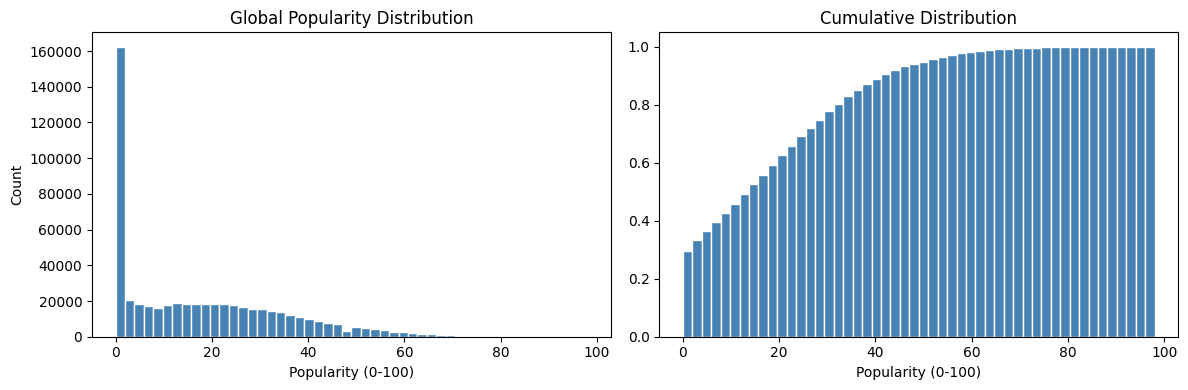

count    550622.000000
mean         17.575954
std          17.457960
min           0.000000
25%           0.000000
50%          14.000000
75%          30.000000
max          98.000000
Name: popularity, dtype: float64

Songs with 0 popularity: 148,778 (27.0%)


In [34]:
# -- 2.2 Popularity Distribution --
fig, axes = plt.subplots(1,2,figsize=(12,4))

axes[0].hist(df['popularity'],bins=50, color='steelblue',edgecolor='white')
axes[0].set_title('Global Popularity Distribution')
axes[0].set_xlabel('Popularity (0-100)')
axes[0].set_ylabel('Count')

axes[1].hist(df['popularity'],bins=50,color='steelblue',edgecolor='white',cumulative=True,density=True)
axes[1].set_title('Cumulative Distribution')
axes[1].set_xlabel('Popularity (0-100)')

plt.tight_layout()
plt.show()

print(df['popularity'].describe())
print(f'\nSongs with 0 popularity: {(df['popularity']==0).sum():,} ({(df['popularity']==0).mean()*100:.1f}%)')

**Observations — 2.2 Popularity Distribution**
- **Heavily right-skewed.** Massive spike at 0 — most songs have very low popularity.
- Mean = 17.6, Median = 14, 75th percentile = 30. The vast majority of songs score below 30.
- Max = 98 (not 100), so even the most popular songs don't hit the ceiling.
- The cumulative plot confirms: ~40% of songs have popularity ≤ 5, and ~80% are below 35.
- **Implication for sampling:** A naive random sample would be overwhelmingly "Low" popularity. We need stratified sampling with engineered popularity bins to get balanced classes.

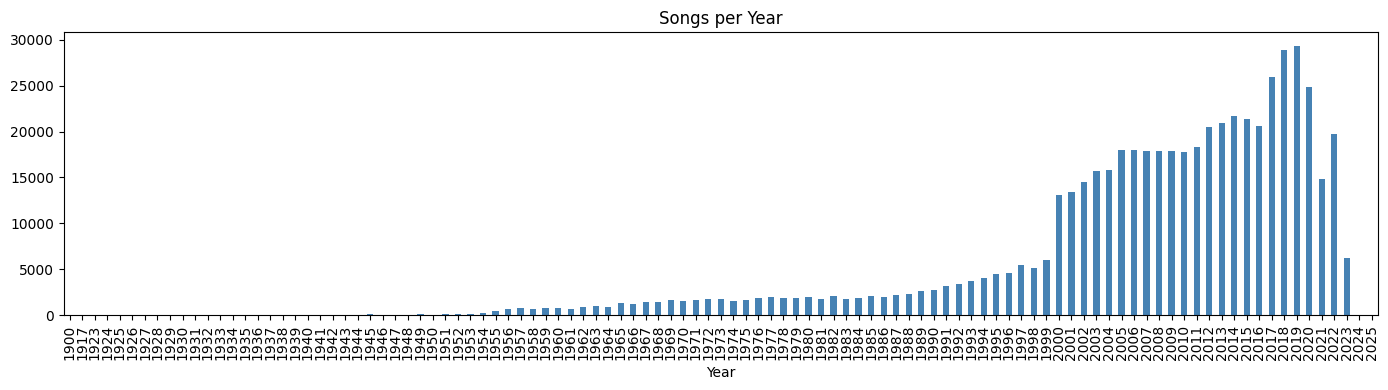

Songs from 2010 onward: 290,872


In [35]:
# -- 2.3 Year Distribution ---
if 'year' in df.columns:
    df['year'].value_counts().sort_index().plot(kind='bar',figsize=(14,4),color='steelblue')
    plt.title('Songs per Year')
    plt.xlabel('Year')
    plt.tight_layout()
    plt.show()
    print(f'Songs from 2010 onward: {(df['year']>=2010).sum():,}')

**Observations — 2.3 Year Distribution**
- Exponential growth in song count from ~2010 onward, peaking around 2020.
- **290,872 songs from 2010+** — over half the dataset. Pre-2000 data is sparse.
- Older songs likely have unreliable popularity scores (Spotify popularity is based on recent streaming activity, so older catalog tracks are naturally disadvantaged).
- **Implication:** Filtering to recent years (2010+ or 2015+) removes temporal bias and keeps the majority of data.

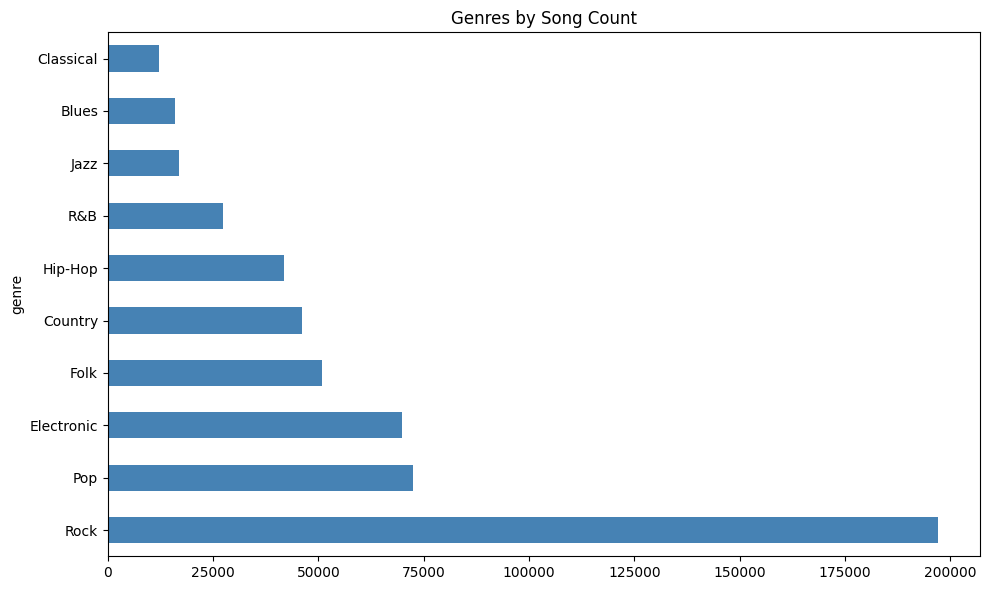

Total Unique Genres: 10


In [53]:
# -- 2.4 Genre Distribution --
if 'genre' in df.columns:
    top_genres = df['genre'].value_counts().head(20)
    top_genres.plot(kind='barh',figsize=(10,6),color='steelblue')
    plt.title('Genres by Song Count')
    plt.tight_layout()
    plt.show()
    print(f'Total Unique Genres: {df['genre'].nunique()}')



**Observations — 2.4 Genre Distribution**
- Only **10 unique genres** — these are broad umbrella categories, not fine-grained subgenres (the `niche_genres` column has those).
- **Rock dominates** with ~195k songs ( ~35% of the dataset). Pop and Electronic follow at ~75k and ~65k.
- Significant class imbalance: Rock has ~15x more songs than Classical.
- **Implication:** When building the genre-relative popularity label, genres with fewer songs (Classical, Blues, Jazz) will have noisier percentile rankings. Sampling should account for this imbalance.

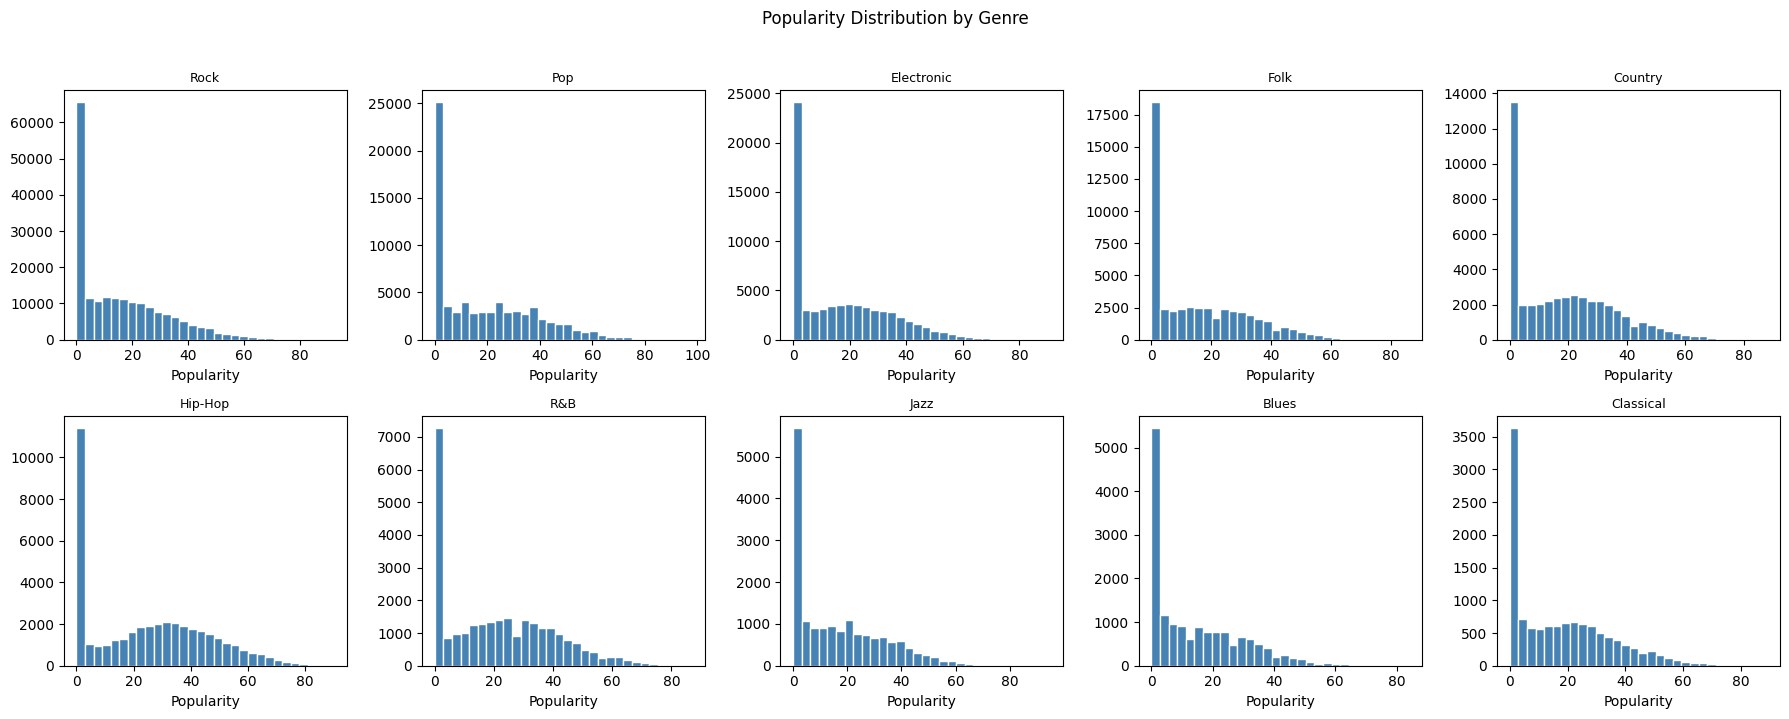

In [37]:
# -- 2.5 Popularity within Top Genres --
# Question: does popularity distribution vary by genre?
if 'genre' in df.columns:
    top_10_genres = df['genre'].value_counts().head(10).index
    fig, axes = plt.subplots(2, 5, figsize=(18,7), sharey=False)

    for ax, genre in zip(axes.flatten(), top_10_genres):
        subset = df[df['genre'] == genre]['popularity']
        ax.hist(subset,bins=30,color='steelblue',edgecolor='white')
        ax.set_title(genre[:20],fontsize=9)
        ax.set_xlabel('Popularity')

    plt.suptitle('Popularity Distribution by Genre',y=1.02)
    plt.tight_layout()
    plt.show()

**Observations — 2.5 Popularity within Top Genres**
- **Every genre is right-skewed**, but the shapes differ meaningfully:
  - **Rock, Folk, Country, Classical** — very concentrated near 0, with thin tails. Most songs in these genres are unpopular on Spotify.
  - **Pop, Hip-Hop** — still skewed, but with a wider spread and more songs in the 20-60 range.
  - **Electronic, R&B** — somewhere in between.
- This confirms that "popular" means something different in each genre context — a Pop song at popularity 30 is average, but a Classical song at 30 is a standout.
- **Implication:** This validates the need for a **genre-relative popularity label** (Research Question 2). A global threshold alone would systematically undercount "popular" songs in niche genres.

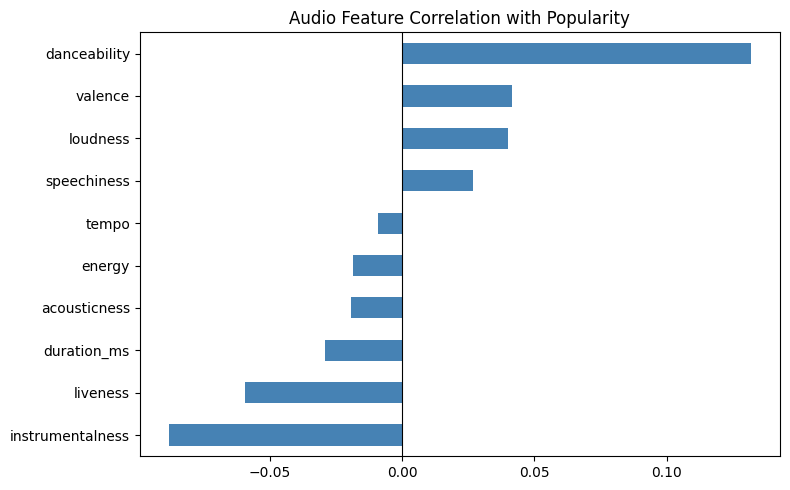

In [38]:
# -- 2.6 Feature Correlation with Popularity --
AUDIO_FEATURES = [
    'danceability','energy','loudness',
    'speechiness','acousticness','instrumentalness',
    'liveness','valence','tempo','duration_ms'
]
valid_features = [f for f in AUDIO_FEATURES if f in df.columns]

corr = df[valid_features + ['popularity']].corr()['popularity'].drop('popularity').sort_values()
corr.plot(kind='barh',figsize=(8,5),color='steelblue')
plt.title('Audio Feature Correlation with Popularity')
plt.axvline(0,color='black',linewidth=0.8)
plt.tight_layout()
plt.show()

**Observations — 2.6 Feature Correlation with Popularity**
- **All correlations are weak** (none exceed |0.15|). No single audio feature is a strong linear predictor of popularity.
- **Danceability** is the strongest positive predictor (~0.13) — danceable songs tend to be slightly more popular.
- **Instrumentalness** is the strongest negative predictor (~-0.06) — songs without vocals tend to be less popular.
- **Loudness, valence, speechiness** have small positive correlations; **liveness, duration_ms, acousticness** are slightly negative.
- Energy and tempo are near zero — essentially no linear relationship.
- **Implication:** Since individual features are weak, classification will likely depend on **feature interactions** rather than any single feature. This is why non-linear models (Decision Trees, Neural Networks) may outperform Naive Bayes here. Also supports the idea that genre context could unlock signal that global correlations miss.

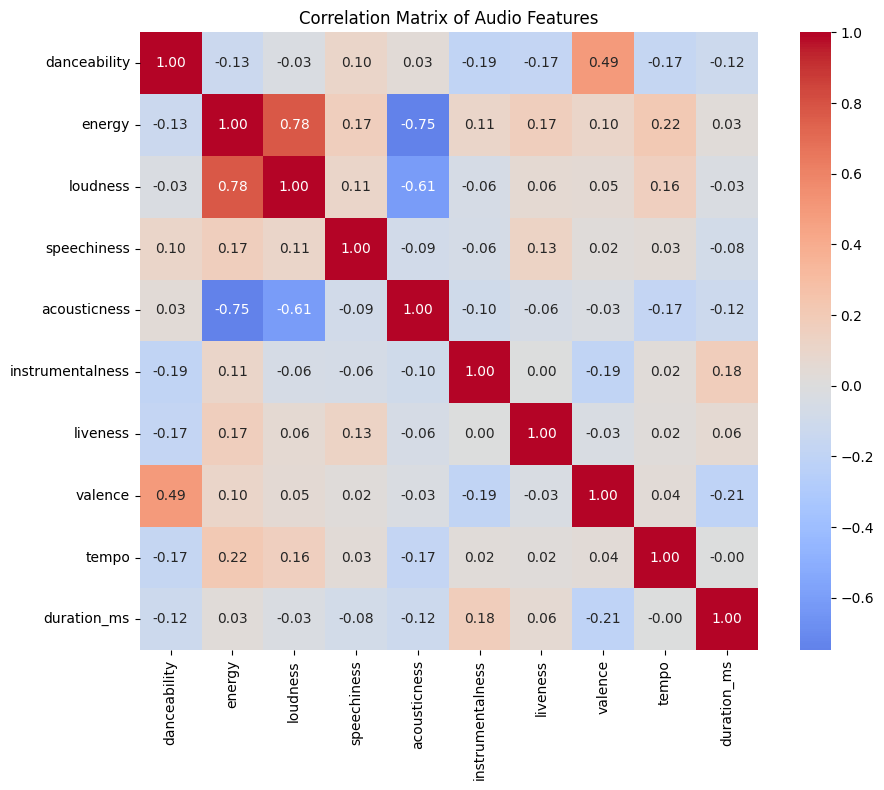

 High correlation: energy vs loudness = 0.777
 High correlation: energy vs acousticness = -0.749
 High correlation: loudness vs acousticness = -0.606


In [39]:
# -- 2.7 Multicollinearity check --
# If 2 features are highly correlated w/ EO, they add redundancy
corr_matrix = df[valid_features].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0, square=True)
plt.title("Correlation Matrix of Audio Features")
plt.tight_layout()
plt.show()

# Flag any pairs with |corr| > 0.5
for i in range(len(valid_features)):
    for j in range(i + 1, len(valid_features)):
      r = corr_matrix.iloc[i, j]
      if abs(r) > 0.5:
        print(f" High correlation: {valid_features[i]} vs {valid_features[j]} = {r:.3f}")

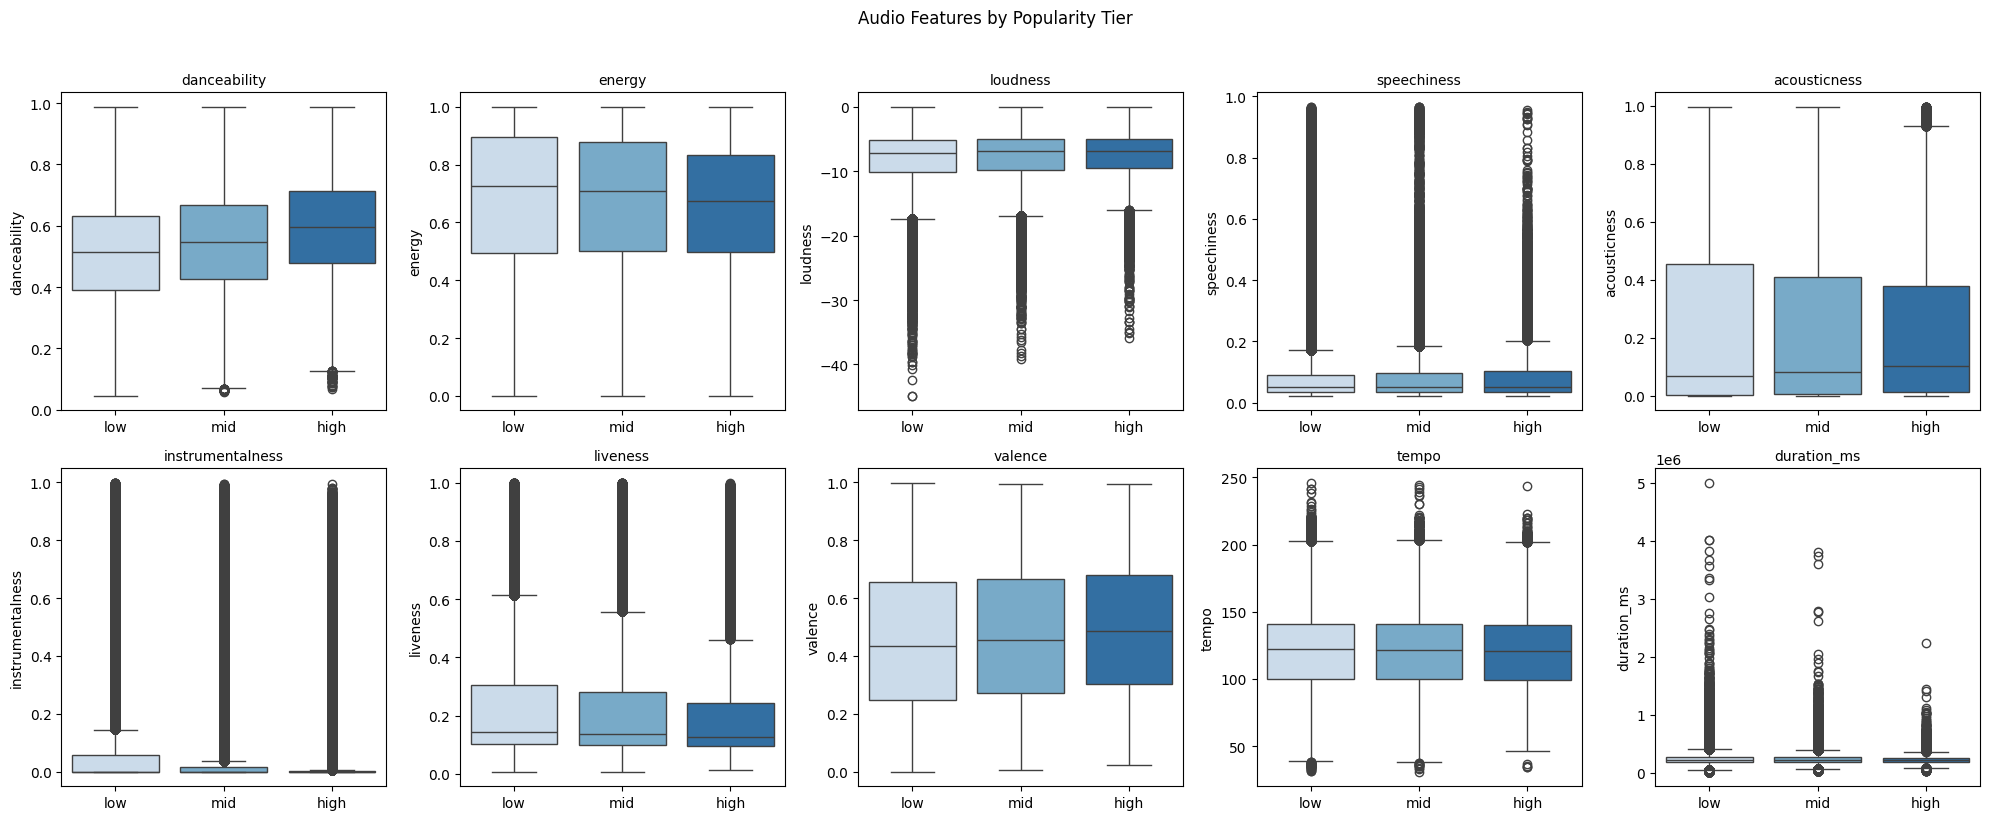

In [40]:
# -- 2.8 Box plots: audio features by popularity tier --
# Quick check: are the classes actually separable on any feature?
temp = df.copy()
temp['pop_tier'] = pd.cut(temp['popularity'], bins=[0,20,45,100], labels=['low','mid','high'], include_lowest=True)

fig, axes = plt.subplots(2,5,figsize=(20,8))
for ax, feat in zip(axes.flatten(), valid_features):
    sns.boxplot(data=temp, x='pop_tier',y=feat,ax=ax,palette='Blues', order=['low','mid','high'])
    ax.set_title(feat, fontsize=10)
    ax.set_xlabel('')

plt.suptitle('Audio Features by Popularity Tier',y=1.02)
plt.tight_layout()
plt.show()

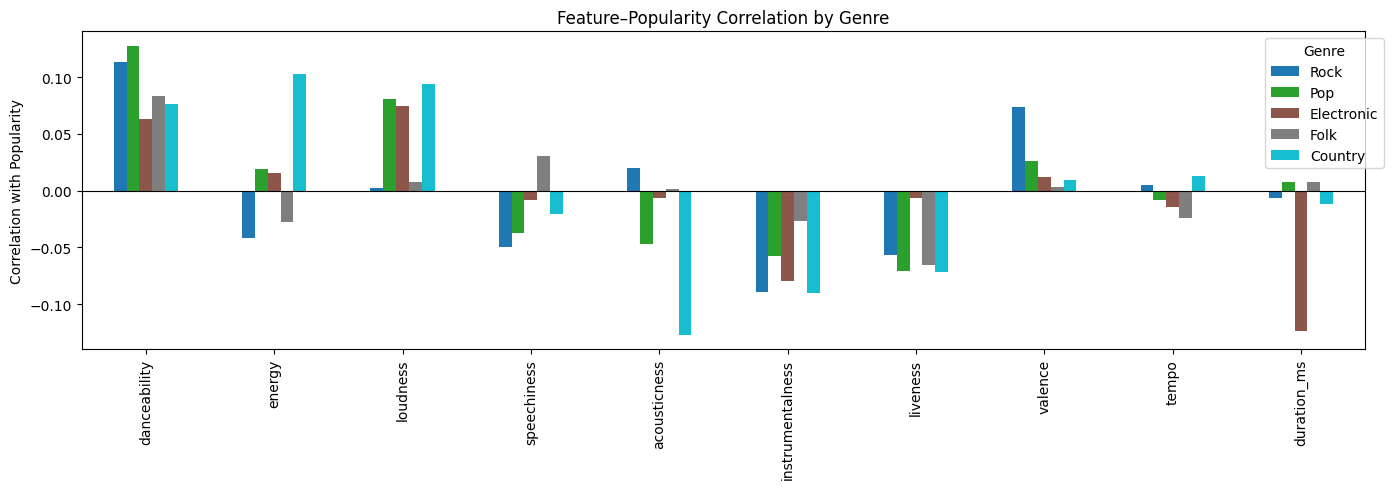

In [41]:
# -- 2.9 Genre-stratified correlations --
# Does danceability predict popularity differently in Hip-Hop vs Classical?
top_5_genres = df['genre'].value_counts().head(5).index

genre_corrs = {}
for genre in top_5_genres:
    subset = df[df['genre'] == genre]
    genre_corrs[genre] = subset[valid_features + ['popularity']].corr()['popularity'].drop('popularity')

genre_corr_df = pd.DataFrame(genre_corrs)
genre_corr_df.plot(kind='bar', figsize=(14, 5), colormap='tab10')
plt.title('Feature\u2013Popularity Correlation by Genre')
plt.ylabel('Correlation with Popularity')
plt.axhline(0, color='black', linewidth=0.8)
plt.legend(title='Genre', bbox_to_anchor=(1.02, 1))
plt.tight_layout()
plt.show()

---
# 3. Sample
- Filter 2000-present (2023)
- Bin popularity into `low` / `mid` / `high`
- Stratified sample for balanced across both popularity class and genre

In [42]:
# -- 3.1 Filter to recent songs ---
df_recent = df[df['year'] >= 2010].copy()
print(f'Songs after 2010 filter: {len(df_recent):,}')

Songs after 2010 filter: 290,872


In [43]:
# -- 3.2 Global popularity label --
# Thresholds: 0-20 (Low) / 21-45 (Mid) / 46+ (High)
def bin_popularity(score, low_max=20, high_min=46):
    if score <= low_max:
        return 'Low'
    elif score >= high_min:
        return 'High'
    else:
        return 'Mid'

df_recent['popularity_class'] = df_recent['popularity'].apply(bin_popularity)
print(df_recent['popularity_class'].value_counts())
print(f'\nClass ratios:\n{df_recent["popularity_class"].value_counts(normalize=True).round(3)}')

popularity_class
Low     174406
Mid      92565
High     23901
Name: count, dtype: int64

Class ratios:
popularity_class
Low     0.600
Mid     0.318
High    0.082
Name: proportion, dtype: float64


In [44]:
# --- 3.3 Genre-relative popularity label ---
# Rank each song's popularity within its genre, then bin by percentile
df_recent['genre_popularity_rank'] = df_recent.groupby('genre')['popularity'].rank(pct=True)

def bin_genre_rank(rank):
    if rank <= 0.33:
        return 'Low'
    elif rank >= 0.67:
        return 'High'
    else:
        return 'Mid'

df_recent['genre_popularity_class'] = df_recent['genre_popularity_rank'].apply(bin_genre_rank)
print(df_recent['genre_popularity_class'].value_counts())

genre_popularity_class
Mid     99918
High    95550
Low     95404
Name: count, dtype: int64


In [45]:
# -- 3.4 Stratified sample: balanced across popularity class and genre --
# Group by (popularity_class, genre) so small genres aren't wiped out
SAMPLE_PER_GROUP = 500  # per (popularity_class, genre) pair

sampled = (
    df_recent
    .groupby(['popularity_class', 'genre'], group_keys=False)
    .apply(lambda x: x.sample(min(len(x), SAMPLE_PER_GROUP), random_state=SEED))
)
print(f'Sampled dataset: {len(sampled):,} songs')
print(f'\nBy popularity class:\n{sampled["popularity_class"].value_counts()}')
print(f'\nBy genre:\n{sampled["genre"].value_counts()}')

Sampled dataset: 14,537 songs

By popularity class:
popularity_class
Low     5000
Mid     5000
High    4537
Name: count, dtype: int64

By genre:
genre
Classical     1500
Country       1500
Pop           1500
Electronic    1500
Folk          1500
Hip-Hop       1500
Rock          1500
R&B           1500
Jazz          1329
Blues         1208
Name: count, dtype: int64


# 4. Preprocess
clean and scale the sampled data

In [46]:
# -- 4.1 Select features and drop missing --
CATEGORICAL_FEATURES = ['key', 'mode']
ALL_FEATURES = valid_features + CATEGORICAL_FEATURES

sampled = sampled.dropna(subset=ALL_FEATURES)
print(f'After dropping missing: {len(sampled):,}')

After dropping missing: 14,537


In [47]:
# -- 4.2 Encode Key --
X = sampled[ALL_FEATURES].copy()

# Scale continuous features
scaler = MinMaxScaler()
X[valid_features] = scaler.fit_transform(X[valid_features])

# Labels
label_map = {'Low': 0, 'Mid': 1, 'High': 2}
y_global = sampled['popularity_class'].map(label_map)
y_genre  = sampled['genre_popularity_class'].map(label_map)

print('Feature matrix shape:', X.shape)
print('Label distribution (global):', y_global.value_counts().to_dict())

Feature matrix shape: (14537, 12)
Label distribution (global): {0: 5000, 1: 5000, 2: 4537}


In [48]:
# -- 4.3 Train/test split --
X_train, X_test, y_train_g, y_test_g, y_train_gr, y_test_gr = train_test_split(
    X, y_global, y_genre, test_size=0.2, random_state=SEED, stratify=y_global
)
print(f'Train: {len(X_train):,} | Test: {len(X_test):,}')

Train: 11,629 | Test: 2,908


# 5. Baseline Classifiers
KNN, Decision Tree, and Naive Bayes

In [49]:
def evaluate(name, model, X_tr, y_tr, X_te, y_te):
    model.fit(X_tr, y_tr)
    preds = model.predict(X_te)
    print(f'\n=== {name} ===')
    print(classification_report(y_te, preds, target_names=['Low', 'Mid', 'High']))
    cm = confusion_matrix(y_te, preds)
    disp = ConfusionMatrixDisplay(cm, display_labels=['Low', 'Mid', 'High'])
    disp.plot(cmap='Blues')
    plt.title(name)
    plt.show()
    return model

-- TARGET: GLOBAL POPULARITY --

=== KNN (k=5) ===
              precision    recall  f1-score   support

         Low       0.37      0.48      0.42      1000
         Mid       0.35      0.35      0.35      1000
        High       0.32      0.22      0.26       908

    accuracy                           0.35      2908
   macro avg       0.35      0.35      0.34      2908
weighted avg       0.35      0.35      0.35      2908



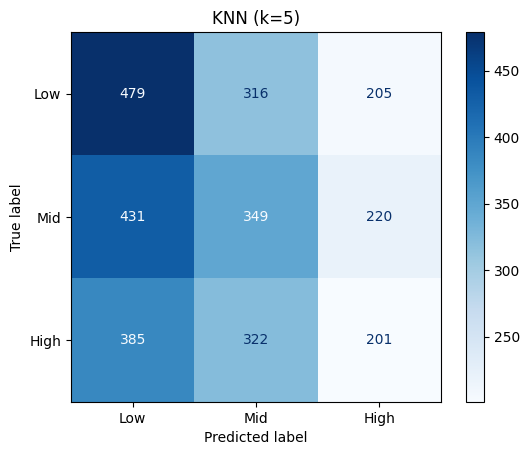


=== Decision Tree ===
              precision    recall  f1-score   support

         Low       0.40      0.47      0.43      1000
         Mid       0.35      0.33      0.34      1000
        High       0.39      0.35      0.37       908

    accuracy                           0.38      2908
   macro avg       0.38      0.38      0.38      2908
weighted avg       0.38      0.38      0.38      2908



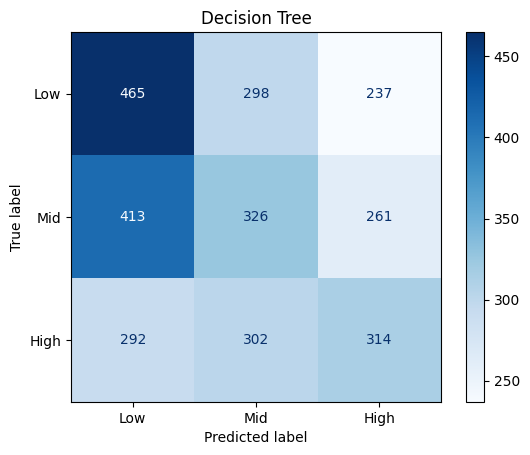


=== Naive Bayes ===
              precision    recall  f1-score   support

         Low       0.44      0.32      0.37      1000
         Mid       0.35      0.16      0.22      1000
        High       0.38      0.72      0.50       908

    accuracy                           0.39      2908
   macro avg       0.39      0.40      0.36      2908
weighted avg       0.39      0.39      0.36      2908



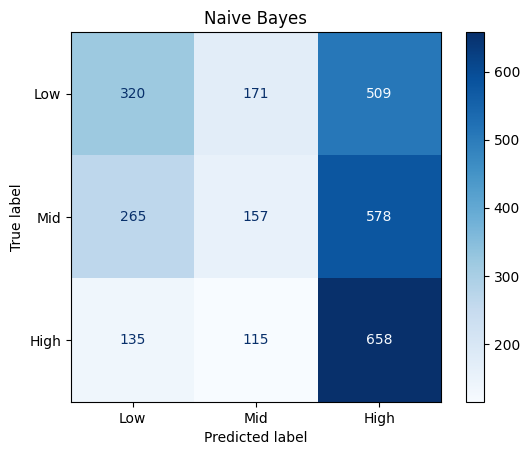

In [50]:
# -- 5.1 Global popularity target --
print('-- TARGET: GLOBAL POPULARITY --')

knn = evaluate('KNN (k=5)', KNeighborsClassifier(n_neighbors=5),
               X_train, y_train_g, X_test, y_test_g)

dt  = evaluate('Decision Tree', DecisionTreeClassifier(max_depth=10, random_state=SEED),
               X_train, y_train_g, X_test, y_test_g)

nb  = evaluate('Naive Bayes', GaussianNB(),
               X_train, y_train_g, X_test, y_test_g)

# 6. Neural Network (PyTorch/Sklearn MLP)


In [51]:
# -- 6.1 Model definition --
class PopularityMLP(nn.Module):

SyntaxError: incomplete input (2074143905.py, line 2)